# Eval Trained Generator

In [1]:
from spectrogan import load_model, load_data, plot_generated_data, get_specs
from specforge import CustomFeatureExtractor


torch_device = 'cuda'

# Load model
model, config = load_model('model/generator.pt')
model.to(torch_device)

#Instantiate Feature Extractor
extractor = CustomFeatureExtractor.from_sample_rate(
    sample_rate=config.sample_rate,
    window_length=config.window_size_secs,
    spec_freq_dim=config.spec_freq_dim,
    spec_time_dim=config.spec_time_dim,
).to(torch_device)

In [2]:
generated_waveforms = model.generate(4, device=torch_device)

In [3]:
generated_spectrograms = get_specs(generated_waveforms, extractor).transpose(1,2)

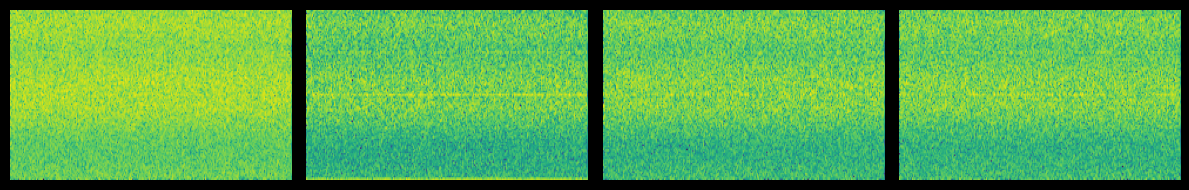

In [4]:
plot_generated_data(generated_spectrograms)